In [3]:
import os
import sys
sys.path.append('../.')
from utils.utils import save_image_grid_with_labels, get_concept_index
import argparse
import numpy as np
from pathlib import Path
import yaml
import torch
from ast import literal_eval
from torch.autograd import Variable
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
from torch import nn
from models import cbae_stygan2
from torchvision import transforms, models
from utils import gan_loss
import itertools
import warnings
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from eval.eval_intervention_gan import opt_int
import time

### Setup

* The next code block sets up the hyperparameters for the visualization.
* Use `optint=True` to use optimization-based interventions and `optint=False` for CB-AE interventions.
* Select target concept from:
    - Smiling
    - Mouth_Slightly_Open
    - Male
    - Arched_Eyebrows
    - Heavy_Makeup
    - High_Cheekbones
    - Wearing_Lipstick
    - Attractive
* Use `concept_value=1` for intervention target to be target concept (e.g. Smiling) and `concept_value=0` for opposite of target concept (e.g. Not Smiling).

In [5]:
# dataset to evaluate on
dataset = 'celebahq'
# experiment name
expt_name = 'cbae_stygan2_thr90'
# tensorboard name
tensorboard_name = 'sup_pl_unk40_cls8'
# whether to use optimization-based interventions
optint = True
optint_eps = 0.1
optint_iters = 50

# target concept and target value (desired concept to intervene on), e.g. "Smiling", "Mouth_Slightly_Open", "Male"
target_concept = 'Mouth_Slightly_Open'
## e.g. 0 or 1 (since all concepts in CelebA-HQ are binary)
concept_value = 0

clsf_model_type = 'rn18'
device = 'cuda:0'

### Load generative model with CB-AE

In [6]:
config_file = f"../config/{expt_name}/"+dataset+".yaml"

with open(config_file, 'r') as stream:
    config = yaml.safe_load(stream)
print(f"Loaded configuration file {config_file}")

Loaded configuration file ../config/cbae_stygan2_thr90/celebahq.yaml


In [7]:
num_cls = 8
set_of_classes = [
    ['NOT Attractive', 'Attractive'],
    ['NO Lipstick', 'Wearing Lipstick'],
    ['Mouth Closed', 'Mouth Slightly Open'],
    ['NOT Smiling', 'Smiling'],
    ['Low Cheekbones', 'High Cheekbones'],
    ['NO Makeup', 'Heavy Makeup'],
    ['Female', 'Male'],
    ['Straight Eyebrows', 'Arched Eyebrows']
]
conc_clsf_classes = [
    'Attractive',
    'Wearing_Lipstick',
    'Mouth_Slightly_Open',
    'Smiling',
    'High_Cheekbones',
    'Heavy_Makeup',
    'Male',
    'Arched_Eyebrows',
]

concept_change = conc_clsf_classes.index(target_concept)
config['model']['pretrained'] = '../models/checkpoints/stylegan2-celebahq-256x256.pkl'
model = cbae_stygan2.cbAE_StyGAN2(config)

cbae_ckpt_path = f'../models/checkpoints/{dataset}_{expt_name}_{tensorboard_name}_cbae.pt'

model.cbae.load_state_dict(torch.load(cbae_ckpt_path, map_location='cpu'))
model.to(device)
model.eval();

loading stylegan2 from ../models/checkpoints/stylegan2-celebahq-256x256.pkl
Total concepts (including unknown): 56
number of layers in CB-AE: 20


### Load concept classifier to evaluate concept interventions

In [9]:
if clsf_model_type == 'rn18':
    con_clsf = models.resnet18(weights='DEFAULT')
    num_features = con_clsf.fc.in_features
    con_clsf.fc = nn.Linear(num_features, 2) # binary classification (num_of_class == 2)
elif clsf_model_type == 'rn50':
    con_clsf = models.resnet50(weights='DEFAULT')
    num_features = con_clsf.fc.in_features
    con_clsf.fc = nn.Linear(num_features, 2) # binary classification (num_of_class == 2)
elif clsf_model_type == 'vit_l_16':
    con_clsf = models.vit_l_16(weights='ViT_L_16_Weights.IMAGENET1K_SWAG_E2E_V1')
    num_features = con_clsf.heads.head.in_features
    con_clsf.heads = nn.Linear(num_features, 2)

con_clsf.load_state_dict(torch.load(f'../models/checkpoints/{dataset}_{target_concept}_{clsf_model_type}_conclsf.pth', map_location='cpu'))
print(f'loading concept classifier from models/checkpoints/{dataset}_{target_concept}_{clsf_model_type}_conclsf.pth')
con_clsf = con_clsf.to(device)
con_clsf.eval()

tf_conclsf = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
if clsf_model_type == 'vit_l_16':
    ### generated by chatgpt
    class ResizeNormalizeTransform:
        def __init__(self, resize_size=(512, 512), mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
            self.resize_size = resize_size
            self.normalize = transforms.Normalize(mean, std)

        def __call__(self, img_tensor):
            # Resize the tensor using interpolate (for BxCxHxW input)
            img_tensor = F.interpolate(img_tensor, size=self.resize_size, mode='bilinear', align_corners=False)
            # Normalize the tensor
            return self.normalize(img_tensor)

    tf_conclsf = ResizeNormalizeTransform()

loading concept classifier from models/checkpoints/celebahq_Mouth_Slightly_Open_rn18_conclsf.pth


### Perform concept interventions

In [10]:
batch_size = 16
num_steps = 20

orig_images_list = []
interv_images_list = []
for idx in tqdm(range(num_steps)):
    # intervene on one selected concept with selected value
    concept_change = concept_change
    concept_value = concept_value

    # Sample noise and labels as generator input
    z = torch.randn((batch_size, model.gen.z_dim), device=device)
    latent = model.gen.mapping(z, None, truncation_psi=1.0, truncation_cutoff=None)

    if optint:
        recon_latent = latent.detach().clone()
        new_latent = opt_int(model, latent, concept_change, concept_value, num_iters=optint_iters, eps=optint_eps, device=device)

    concepts = model.cbae.enc(latent)

    new_concepts = concepts.clone()

    start, end = get_concept_index(model, concept_change)
    c_concepts = concepts[:, start:end]
    _, num_c = c_concepts.shape

    # swapping the max value to the concept we need
    new_c_concepts = c_concepts.clone()
    old_vals = new_c_concepts[:, concept_value].clone()
    max_val, max_ind = torch.max(new_c_concepts, dim=1)
    new_c_concepts[:, concept_value] = max_val
    for swap_idx, (curr_ind, curr_old_val) in enumerate(zip(max_ind, old_vals)):
        new_c_concepts[swap_idx, curr_ind] = curr_old_val

    new_concepts[:, start:end] = new_c_concepts

    if not optint:
        new_latent = model.cbae.dec(new_concepts)
    recon_latent = model.cbae.dec(concepts)

    # Generate a batch of images
    gen_imgs_latent = model.gen.synthesis(new_latent, noise_mode='const')
    gen_imgs_latent_orig = model.gen.synthesis(recon_latent, noise_mode='const')

    gen_imgs_latent = gen_imgs_latent.mul(0.5).add_(0.5)
    gen_imgs_latent_orig = gen_imgs_latent_orig.mul(0.5).add_(0.5)

    # converting it to the normalization required by ResNet18 concept classifier
    gen_imgs_latent_cc = tf_conclsf(gen_imgs_latent)
    gen_imgs_latent_orig_cc = tf_conclsf(gen_imgs_latent_orig)

    interv_pred = con_clsf(gen_imgs_latent_cc).argmax(dim=1)
    recon_pred = con_clsf(gen_imgs_latent_orig_cc).argmax(dim=1)

    # pick out samples which do not have the desired concept value (to see change with intervention)
    curr_mask = (recon_pred != concept_value)
    if gen_imgs_latent.data[curr_mask].numel() != 0:
        orig_imgs = save_image_grid_with_labels(gen_imgs_latent_orig.data[curr_mask], recon_pred[curr_mask], set_of_classes[concept_change], grid_size=(4, 4), file_name=None, return_images=True).detach().cpu()
        interv_imgs = save_image_grid_with_labels(gen_imgs_latent.data[curr_mask], interv_pred[curr_mask], set_of_classes[concept_change], grid_size=(4, 4), file_name=None, return_images=True).detach().cpu()
        orig_images_list.append(orig_imgs)
        interv_images_list.append(interv_imgs)

orig_images = torch.cat(orig_images_list, dim=0)
interv_images = torch.cat(interv_images_list, dim=0)

orig_grid = make_grid(orig_images[:64], nrow=8, padding=2, normalize=True)
interv_grid = make_grid(interv_images[:64], nrow=8, padding=2, normalize=True)

  0%|          | 0/20 [00:00<?, ?it/s]

Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.


100%|██████████| 20/20 [02:29<00:00,  7.46s/it]


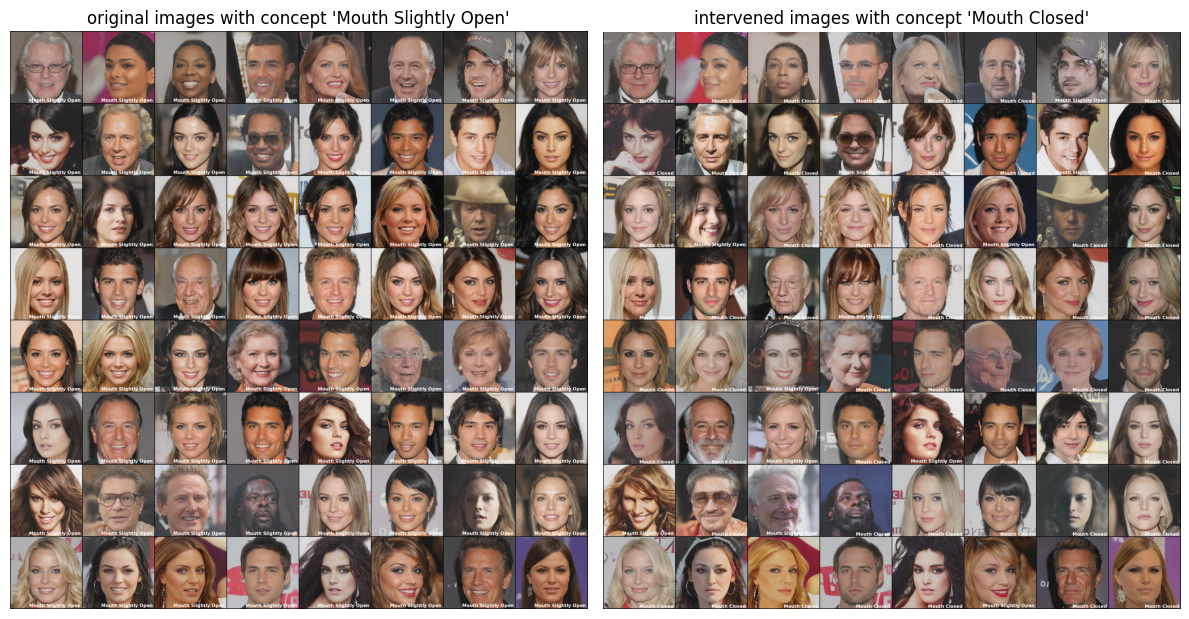

In [11]:
def imshow_grid(grid, title, ax):
    # Convert from torch tensor to numpy image
    npimg = grid.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))  # CHW to HWC
    ax.imshow(npimg)
    ax.set_title(title)
    ax.axis('off')

fig, axs = plt.subplots(1, 2, figsize=(12, 12))

imshow_grid(orig_grid, f"original images with concept \'{set_of_classes[concept_change][1 - concept_value]}\'", axs[0])
imshow_grid(interv_grid, f"intervened images with concept \'{set_of_classes[concept_change][concept_value]}\'", axs[1])

plt.tight_layout()
plt.show()

##Now let's just take a single random face and apply an intervention (smile example).

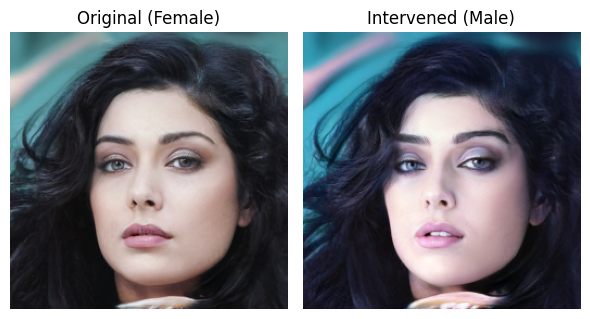

In [66]:
import random
import matplotlib.pyplot as plt

def visualize_single_intervention(model, con_clsf, target_concept, concept_value, device='cuda:0'):
    """
    Samples one latent z, runs both recon (no intervention) and an intervention
    on the specified concept, and plots them side by side.
    """
    # 1) Sample a single latent
    z = torch.randn((1, model.gen.z_dim), device=device)
    latent = model.gen.mapping(z, None, truncation_psi=1.0, truncation_cutoff=None)

    # 2) Recon (no intervention)
    recon_latent = model.cbae.dec(model.cbae.enc(latent))
    orig_img = model.gen.synthesis(recon_latent, noise_mode='const').clamp(-1, 1).mul(0.5).add_(0.5)

    # 3) Optimization‐based intervention (optint must be set True earlier)
    new_latent = opt_int(model, latent,
                        conc_clsf_classes.index(target_concept),
                        concept_value,
                        num_iters=optint_iters,
                        eps=optint_eps,
                        device=device)
    intv_img = model.gen.synthesis(new_latent, noise_mode='const').clamp(-1,1).mul(0.5).add_(0.5)

    # 4) Convert to CPU & normalize for the classifier
    to_display = torch.cat([orig_img, intv_img], dim=0).cpu()

    # 5) Plot
    fig, axes = plt.subplots(1, 2, figsize=(6, 6))
    titles = [
        f"Original ({set_of_classes[concept_change][1 - concept_value]})",
        f"Intervened ({set_of_classes[concept_change][concept_value]})"
    ]
    for ax, img, t in zip(axes, to_display, titles):
        # detach before squeezing & permuting
        npimg = img.detach().cpu().squeeze().permute(1, 2, 0).numpy()
        ax.imshow(npimg)
        ax.set_title(t)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Example call:
visualize_single_intervention(model, con_clsf, target_concept, concept_value, device)

Example #2 Gennder swap  intervenion.



=== Sample 1 ===
Original is Male 🔒 logits=[-2.077267646789551, 0.5323827266693115], probs=[0.06851992011070251, 0.9314801096916199]
After CB-AE swap → logits=[-1.2153788805007935, -0.14352615177631378], probs=[0.2550508975982666, 0.7449491024017334]
After PGD 50% → logits=[1.4072753190994263, -2.232548475265503], probs=[0.9744148850440979, 0.025585178285837173]
After PGD 100% → logits=[1.5188697576522827, -2.491147994995117], probs=[0.9821898937225342, 0.017810121178627014]


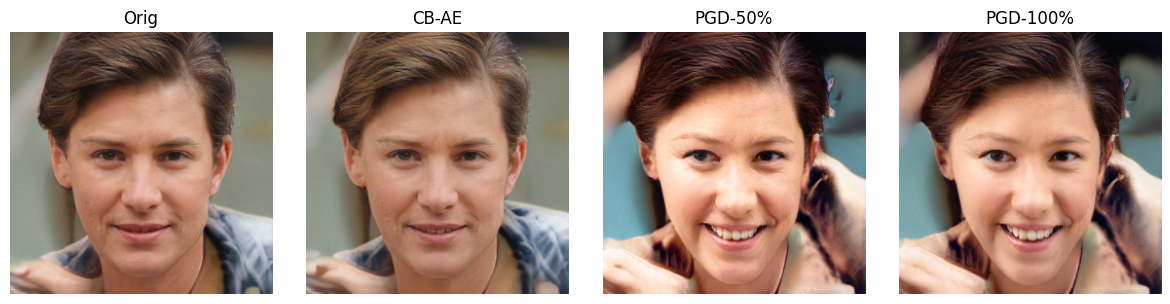


=== Sample 2 ===
Original is Male 🔒 logits=[-3.3998794555664062, 2.1384804248809814], probs=[0.003917565569281578, 0.9960824251174927]
After CB-AE swap → logits=[-2.892728805541992, 2.026277542114258], probs=[0.0072533912025392056, 0.9927466511726379]
After PGD 50% → logits=[-3.1964259147644043, 2.3685007095336914], probs=[0.0038152497727423906, 0.996184766292572]
After PGD 100% → logits=[-2.225571632385254, 1.4831938743591309], probs=[0.02392149716615677, 0.9760785102844238]


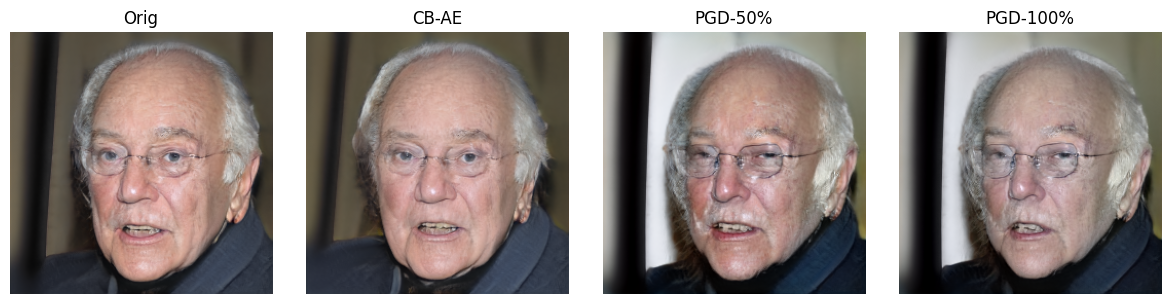


=== Sample 3 ===
Original is Male 🔒 logits=[-3.2238173484802246, 2.2456064224243164], probs=[0.004195978865027428, 0.9958040118217468]
After CB-AE swap → logits=[-1.8379180431365967, 0.7999792098999023], probs=[0.06673888862133026, 0.9332610964775085]
After PGD 50% → logits=[-3.328108787536621, 2.008138656616211], probs=[0.0047908383421599865, 0.9952091574668884]
After PGD 100% → logits=[-2.802204132080078, 1.2500933408737183], probs=[0.017085405066609383, 0.9829146265983582]


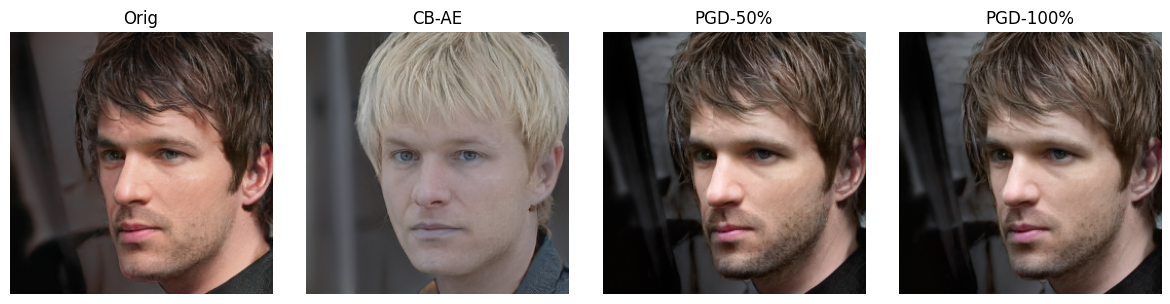

In [35]:
# %% code
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import softmax, one_hot
from utils.utils import get_concept_index

# Identify the gender slice
gender_idx = conc_clsf_classes.index('Male')
start, end = get_concept_index(model, gender_idx)
slice_size = end - start  # should be 2

# Classifier helper that returns (logits, probs)
def get_gender_scores(img):
    """
    img: [C,H,W] in [0,1]
    returns: logits (2,), probs (2,) for [Female, Male]
    """
    x      = tf_conclsf(img.unsqueeze(0))  # [1,C,H,W]
    logits = con_clsf(x)[0]                 # [2]
    probs  = softmax(logits, dim=0)         # [2]
    return logits.detach().cpu().tolist(), probs.detach().cpu().tolist()

# PGD params
full_steps = optint_iters
half_steps = full_steps // 2
eps        = optint_eps

for sample_i in range(1, 4):
    print(f"\n=== Sample {sample_i} ===")
    # 1) Sample a high-confidence male
    for _ in range(100):
        z      = torch.randn((1, model.gen.z_dim), device=device)
        w      = model.gen.mapping(z, None, truncation_psi=1.0)
        img_o  = model.gen.synthesis(model.cbae.dec(model.cbae.enc(w)),
                                     noise_mode='const').clamp(-1,1).mul(0.5).add_(0.5)[0]
        logits_o, probs_o = get_gender_scores(img_o)
        if probs_o[1] > 0.9:  # index 1 = Male
            print("Original is Male 🔒",
                  f"logits={logits_o}, probs={probs_o}")
            break
    else:
        raise RuntimeError("Could not find a confident Male")

    # 2) CB-AE bottleneck swap to Female
    c_orig = model.cbae.enc(w)
    c_fem  = c_orig.clone()
    c_fem[:, start:end] = 0
    # one-hot to Female (index 0)
    c_fem[:, start:end] = one_hot(torch.tensor([0], device=device), num_classes=slice_size).float()
    img_b   = model.gen.synthesis(model.cbae.dec(c_fem),
                                   noise_mode='const').clamp(-1,1).mul(0.5).add_(0.5)[0]
    logits_b, probs_b = get_gender_scores(img_b)
    print("After CB-AE swap →",
          f"logits={logits_b}, probs={probs_b}")

    # 3) Half‐step PGD
    w_half = opt_int(model, w, gender_idx, 0,
                     num_iters=half_steps, eps=eps, device=device)
    img_h   = model.gen.synthesis(w_half,
                                   noise_mode='const').clamp(-1,1).mul(0.5).add_(0.5)[0]
    logits_h, probs_h = get_gender_scores(img_h)
    print("After PGD 50% →",
          f"logits={logits_h}, probs={probs_h}")

    # 4) Full‐step PGD
    w_full = opt_int(model, w, gender_idx, 0,
                     num_iters=full_steps, eps=eps, device=device)
    img_f   = model.gen.synthesis(w_full,
                                   noise_mode='const').clamp(-1,1).mul(0.5).add_(0.5)[0]
    logits_f, probs_f = get_gender_scores(img_f)
    print("After PGD 100% →",
          f"logits={logits_f}, probs={probs_f}")

    # 5) Quick visualization
    fig, axes = plt.subplots(1, 4, figsize=(12,3))
    for ax, im, stage in zip(axes, [img_o, img_b, img_h, img_f],
                             ['Orig', 'CB-AE', 'PGD-50%', 'PGD-100%']):
        ax.imshow(im.detach().cpu().permute(1,2,0).numpy())
        ax.set_title(stage)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### PGD (Projected Gradient Descent) vs CB-AE Intervention

Comparison between PGD (Projected Gradient Descent) Intervention and CB-AE (Concept-Bottleneck Autoencoder) Direct Swap.
### PGD (Projected Gradient Descent) Intervention

- **What it is:**
  An optimization-based method (often called the CC or “Concept Controller” in the paper) that makes small, iterative tweaks to the GAN’s latent code to maximize the score for a target concept.

- **How it works:**
  1. You start with an initial latent **w**.
  2. At each of **T** steps, compute the gradient of the concept classifier’s loss w.r.t. a perturbation **δ** on **w**.
  3. Take a small step in the direction that most increases the classifier’s confidence in your desired label (e.g. “Female”), then **project** **δ** back into an **ℓ∞-ball** of radius **ε**.
  4. After **T** steps you get **w\*** = **w** + **δ**, which you feed to the generator.

- **Pros:**
  - Finds the minimal change needed to flip the concept
  - Often preserves other attributes

- **Cons:**
  - Slower (requires many forward/backward passes)
  - Can get stuck in local minima or introduce artifacts if **ε** is too large

---

### CB-AE (Concept-Bottleneck Autoencoder) Direct Swap

- **What it is:**
  A feed-forward method that leverages a small autoencoder built on top of the GAN’s latent space, with an explicit “bottleneck” of human-defined concepts.

- **How it works:**
  1. Encode the original latent **w** into a concept vector **c** = *E*(**w**) (e.g. a 56-dim vector where each slice corresponds to one binary attribute).
  2. Overwrite the slice for your target concept with a one-hot vector pointing to your desired value (e.g. set the “gender” slice to `[1, 0]` for Female).
  3. Decode **c** back into a new latent **ŵ** = *D*(**c**) and generate the image in one forward pass.

- **Pros:**
  - Extremely fast (just two small networks)
  - Fully disentangled by design—no gradients needed

- **Cons:**
  - Limited by how well the decoder reconstructs off-manifold concept vectors
  - May produce less realistic or overly “blurry” edits and can inadvertently change correlated attributes
    -




--- Sample 1 ---
Original: NO Lipstick 100.0%
CB-AE swap: NO Lipstick 100.0%
PGD-50%: NO Lipstick 100.0%
PGD-100%: NO Lipstick 100.0%


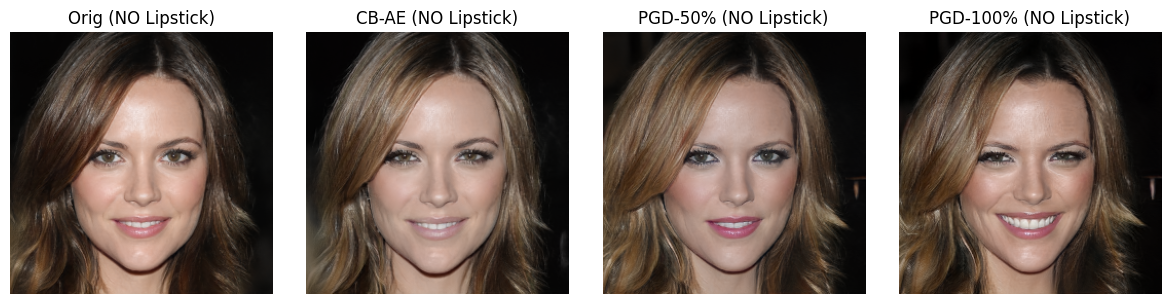


--- Sample 2 ---
Original: NO Lipstick 100.0%
CB-AE swap: NO Lipstick 100.0%
PGD-50%: NO Lipstick 100.0%
PGD-100%: NO Lipstick 100.0%


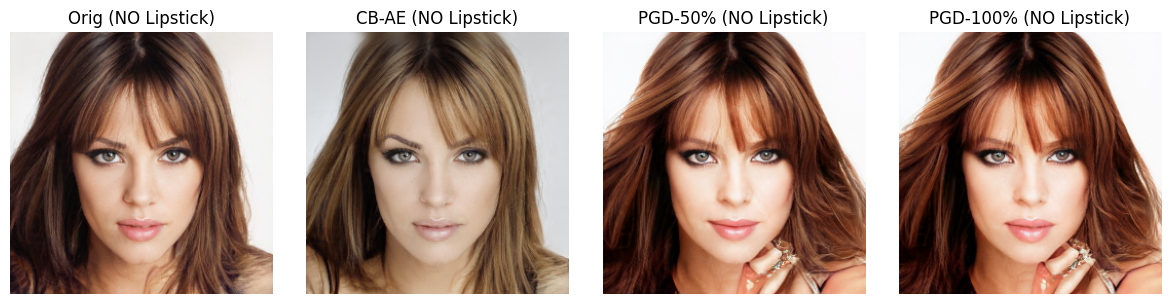


--- Sample 3 ---
Original: NO Lipstick 100.0%
CB-AE swap: NO Lipstick 100.0%
PGD-50%: NO Lipstick 99.9%
PGD-100%: NO Lipstick 99.9%


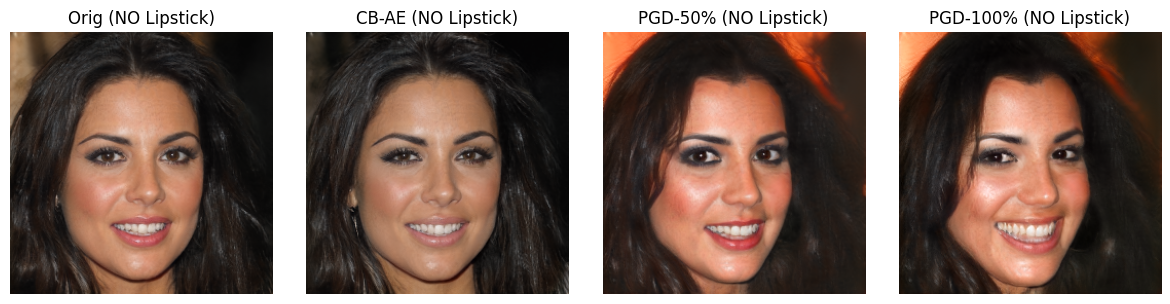

In [39]:
# %% code
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import softmax, one_hot
from utils.utils import get_concept_index

# 1) Setup for “Wearing_Lipstick”
target_concept = 'Wearing_Lipstick'
concept_value  = 1   # 1 = Wearing Lipstick, 0 = No Lipstick
idx            = conc_clsf_classes.index(target_concept)
start, end     = get_concept_index(model, idx)
slice_size     = end - start  # should be 2

# Off/On labels pulled from your metadata
label_off = set_of_classes[idx][0]  # 'NO Lipstick'
label_on  = set_of_classes[idx][1]  # 'Wearing Lipstick'

# 2) Helper to get (label, confidence) from con_clsf
def classify_with_conf(img):
    x      = tf_conclsf(img.unsqueeze(0))       # normalize
    logits = con_clsf(x)[0]                      # [2]
    probs  = softmax(logits, dim=0)              # [2]
    pred   = probs.argmax().item()
    label  = set_of_classes[idx][pred]
    return label, probs[pred].item()

# 3) PGD parameters
full_steps = optint_iters
half_steps = full_steps // 2
eps        = optint_eps

for sample_i in range(1,4):
    print(f"\n--- Sample {sample_i} ---")
    # A) sample until exact “NO Lipstick” original
    for _ in range(50):
        z     = torch.randn((1, model.gen.z_dim), device=device)
        w     = model.gen.mapping(z, None, truncation_psi=1.0)
        img_o = model.gen.synthesis(
                    model.cbae.dec(model.cbae.enc(w)),
                    noise_mode='const'
                ).clamp(-1,1).mul(0.5).add_(0.5)[0]
        lbl_o, conf_o = classify_with_conf(img_o)
        if lbl_o == label_off and conf_o > 0.9:
            print("Original:", lbl_o, f"{conf_o:.1%}")
            break
    else:
        raise RuntimeError(f"No high‐conf {label_off} sample in 50 tries")

    # B) CB-AE bottleneck swap → Lipstick
    c_orig = model.cbae.enc(w)
    c_swap = c_orig.clone()
    c_swap[:, start:end] = 0
    c_swap[:, start:end] = one_hot(
        torch.tensor([concept_value], device=device),
        num_classes=slice_size
    ).float()
    img_bae = model.gen.synthesis(
                  model.cbae.dec(c_swap),
                  noise_mode='const'
              ).clamp(-1,1).mul(0.5).add_(0.5)[0]
    lbl_b, conf_b = classify_with_conf(img_bae)
    print("CB-AE swap:", lbl_b, f"{conf_b:.1%}")

    # C) PGD half-steps (intermediate)
    w_half = opt_int(model, w, idx, concept_value,
                     num_iters=half_steps, eps=eps, device=device)
    img_half = model.gen.synthesis(
                   w_half,
                   noise_mode='const'
               ).clamp(-1,1).mul(0.5).add_(0.5)[0]
    lbl_h, conf_h = classify_with_conf(img_half)
    print("PGD-50%:", lbl_h, f"{conf_h:.1%}")

    # D) PGD full-steps (final)
    w_full = opt_int(model, w, idx, concept_value,
                     num_iters=full_steps, eps=eps, device=device)
    img_full = model.gen.synthesis(
                   w_full,
                   noise_mode='const'
               ).clamp(-1,1).mul(0.5).add_(0.5)[0]
    lbl_f, conf_f = classify_with_conf(img_full)
    print("PGD-100%:", lbl_f, f"{conf_f:.1%}")

    # 4) Plot all four stages
    stages = [img_o, img_bae, img_half, img_full]
    titles = [
        f"Orig ({lbl_o})",
        f"CB-AE ({lbl_b})",
        f"PGD-50% ({lbl_h})",
        f"PGD-100% ({lbl_f})"
    ]
    fig, axes = plt.subplots(1,4,figsize=(12,3))
    for ax, im, t in zip(axes, stages, titles):
        ax.imshow(im.detach().cpu().permute(1,2,0).numpy())
        ax.set_title(t)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## PGD Adversarial Attack on Synthesized Images

A PGD (Projected Gradient Descent) “attack” on your generated images would be an adversarial perturbation designed to fool your concept classifier into predicting the **wrong** label. Here’s how it works:

1. **What it is**
   An iterative pixel-space perturbation that maximizes the loss of your classifier on a given image, subject to an \(\ell_\infty\) constraint \(\|\delta\|_\infty \le \epsilon\).

2. **How it works**
   1. Start with a clean image \(x\) (e.g. your generated face).
   2. Initialize a small random perturbation \(\delta_0 \in [-\epsilon, \epsilon]^n\).
   3. For \(t = 1 \dots T\):
      - Compute the gradient of the loss w.r.t. the perturbed image:
        \[
          g_t \;=\; \nabla_{x'} \, \mathcal{L}\bigl(f(x'_t), y_{\text{true}}\bigr)
        \]
        where \(x'_t = \text{clip}(x + \delta_{t-1}, 0, 1)\).
      - Update via a step of size \(\alpha\):
        \[
          \delta_t = \text{Proj}_{\|\cdot\|_\infty \le \epsilon}\Bigl(\delta_{t-1} + \alpha\,\text{sign}(g_t)\Bigr)
        \]
      - Clip \(x'_t = \text{clip}(x + \delta_t, 0, 1)\).
   4. After \(T\) steps, \(x^* = x + \delta_T\) is your adversarial example.

3. **Pros & Cons**
   - **Pros:**
     - Finds minimal pixel changes that reliably flip your classifier’s decision.
     - A standard way to test your classifier’s robustness.
   - **Cons:**
     - Introduces visible noise if \(\epsilon\) is large.
     - Only attacks the classifier, not the generator itself.

---

### Example PyTorch snippet

```python
import torch
from torch.nn.functional import cross_entropy

def pgd_image_attack(model_clsf, x, y_true, eps=0.03, alpha=0.007, steps=40):
    """
    model_clsf: your concept classifier
    x: [1,C,H,W] input image in [0,1]
    y_true: correct label tensor [1]
    Returns: adversarial image x_adv
    """
    x_adv = x.clone().detach().requires_grad_(True)
    for _ in range(steps):
        logits = model_clsf(tf_conclsf(x_adv))
        loss = cross_entropy(logits, y_true)
        loss.backward()
        # gradient sign step
        grad_sign = x_adv.grad.data.sign()
        x_adv.data = torch.clamp(x_adv.data + alpha * grad_sign, x - eps, x + eps)
        x_adv.data = torch.clamp(x_adv.data, 0, 1)
        x_adv.grad.data.zero_()
    return x_adv.detach()

# Usage:
# 1) Generate an image x and its true label y_true = classifier(x).argmax()
# 2) Call x_adv = pgd_image_attack(con_clsf, x.unsqueeze(0), y_true, eps=0.03)
# 3) Visualize x vs. x_adv to see the adversarial noise


# %% md
### Adversarial PGD Attack on Generated Image

# Generates one face, attacks its “Male/Female” classifier label,
# and displays original vs. adversarial images side by side.

Original prediction: Female (97.3%)
Adversarial prediction: Male (100.0%)


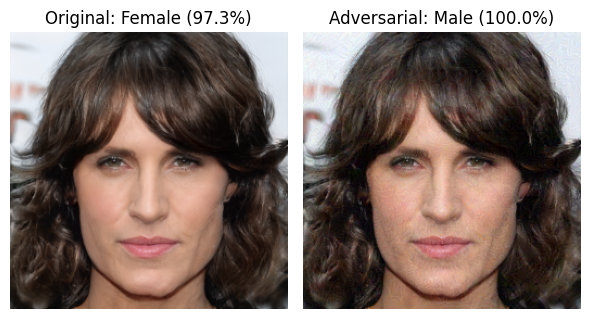

In [41]:
# %% code
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import cross_entropy, softmax

def pgd_image_attack(model_clsf, img, y_true, eps=0.03, alpha=0.005, steps=20):
    """
    model_clsf: classifier (expects normalized input)
    img:       [1,C,H,W] tensor in [0,1]
    y_true:    scalar tensor with the correct label (0 or 1)
    """
    x_adv = img.clone().detach().requires_grad_(True)
    for _ in range(steps):
        logits = model_clsf(tf_conclsf(x_adv))
        loss = cross_entropy(logits, y_true)
        loss.backward()
        # step in sign direction
        x_adv.data = x_adv.data + alpha * x_adv.grad.data.sign()
        # project back into eps-ball around original
        x_adv.data = torch.max(torch.min(x_adv.data, img + eps), img - eps)
        # clamp valid pixel range
        x_adv.data = x_adv.data.clamp(0, 1)
        x_adv.grad.data.zero_()
    return x_adv.detach()

# 1) Sample & synthesize
z = torch.randn((1, model.gen.z_dim), device=device)
w = model.gen.mapping(z, None, truncation_psi=1.0)
img = model.gen.synthesis(w, noise_mode='const').clamp(-1,1).mul(0.5).add_(0.5)  # [-1,1]->[0,1]
img = img  # [1,3,H,W]

# 2) Get “true” label & confidence
with torch.no_grad():
    logits = con_clsf(tf_conclsf(img))
    probs = softmax(logits, dim=1)[0]
    true_label = probs.argmax().unsqueeze(0)  # tensor([0]) or tensor([1])
    true_conf = probs[true_label].item()
    true_name = set_of_classes[conc_clsf_classes.index('Male')][true_label]

print(f"Original prediction: {true_name} ({true_conf:.1%})")

# 3) Attack
img_adv = pgd_image_attack(con_clsf, img, true_label, eps=0.03, alpha=0.005, steps=20)

# 4) Classify adversarial
with torch.no_grad():
    logits2 = con_clsf(tf_conclsf(img_adv))
    probs2 = softmax(logits2, dim=1)[0]
    adv_label = probs2.argmax().item()
    adv_conf  = probs2[adv_label].item()
    adv_name  = set_of_classes[conc_clsf_classes.index('Male')][adv_label]

print(f"Adversarial prediction: {adv_name} ({adv_conf:.1%})")

# 5) Show side by side
fig, axes = plt.subplots(1, 2, figsize=(6,6))
for ax, im, title in zip(axes,
                         [img[0], img_adv[0]],
                         [f"Original: {true_name} ({true_conf:.1%})",
                          f"Adversarial: {adv_name} ({adv_conf:.1%})"]):
    ax.imshow(im.permute(1,2,0).cpu().numpy())
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Continuous Concept Interpolation & Robustness Evaluation

As a secondary extension, we’ll smoothly interpolate a target concept (e.g. “Smiling”) from off→on and evaluate under clean and adversarial conditions.

#### 1. Smooth Interpolation

```python
# %% code
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import get_concept_index

# Settings
target_concept = 'Smiling'
idx            = conc_clsf_classes.index(target_concept)
start, end     = get_concept_index(model, idx)
n_steps        = 10   # number of interpolation points

# 1) Sample one latent and encode
z   = torch.randn((1, model.gen.z_dim), device=device)
w   = model.gen.mapping(z, None, truncation_psi=1.0)
c0  = model.cbae.enc(w)            # original concept vector
c1  = c0.clone()
c1[:, start:end] = one_hot(torch.tensor([1], device=device), num_classes=(end-start)).float()

# 2) Generate interpolated images
imgs = []
for α in np.linspace(0,1,n_steps):
    cα = c0 * (1-α) + c1 * α
    wα = model.cbae.dec(cα)
    img = model.gen.synthesis(wα, noise_mode='const').clamp(-1,1).mul(0.5).add_(0.5)
    imgs.append(img[0].cpu().permute(1,2,0).numpy())

# 3) Plot grid
fig, axes = plt.subplots(1, n_steps, figsize=(2*n_steps,2))
for ax, im, α in zip(axes, imgs, np.linspace(0,1,n_steps)):
    ax.imshow(im)
    ax.set_title(f"{α:.1f}")
    ax.axis('off')
plt.suptitle("Smiling Interpolation (0→1)")
plt.tight_layout()
plt.show()


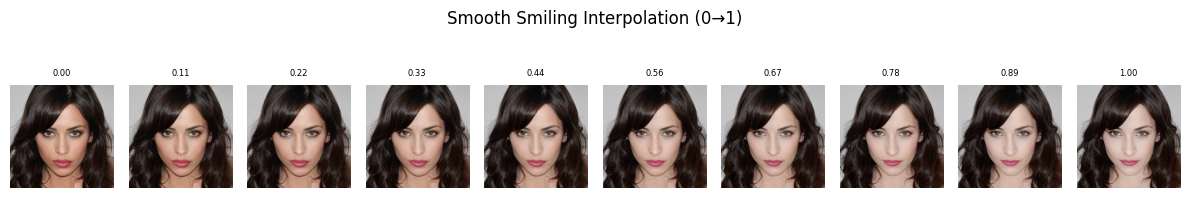

In [48]:
# %% code
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import get_concept_index

# 1) Settings
target_concept = 'Smiling'
n_steps        = 10
idx            = conc_clsf_classes.index(target_concept)
start, end     = get_concept_index(model, idx)

# 2) Sample one latent and get concept endpoints
z   = torch.randn((1, model.gen.z_dim), device=device)
w   = model.gen.mapping(z, None, truncation_psi=1.0)
c0  = model.cbae.enc(w)           # original (no smile)
c1  = c0.clone()
c1[:, start:end] = 0
c1[:, start + 1] = 1.0            # set “Smiling” = on

# 3) Generate interpolated images
imgs = []
alphas = np.linspace(0, 1, n_steps)
for α in alphas:
    cα = c0 * (1 - α) + c1 * α
    wα = model.cbae.dec(cα)
    img = model.gen.synthesis(wα, noise_mode='const')
    img = img.clamp(-1,1).mul(0.5).add_(0.5)  # to [0,1]
    # detach before numpy
    np_img = img[0].detach().cpu().permute(1,2,0).numpy()
    imgs.append(np_img)

# 4) Plot
fig, axes = plt.subplots(1, n_steps, figsize=(n_steps*1.2, 2))
for ax, im, α in zip(axes, imgs, alphas):
    ax.imshow(im)
    ax.set_title(f"{α:.2f}", fontsize=6)
    ax.axis('off')
plt.suptitle("Smooth Smiling Interpolation (0→1)", y=1.05)
plt.tight_layout()
plt.show()

### Smooth “Ugly” → “Pretty” Interpolation (12 steps)

Interpolates the “Attractive” concept from 0 (ugly) → 1 (pretty) in 12 increments and plots the results.

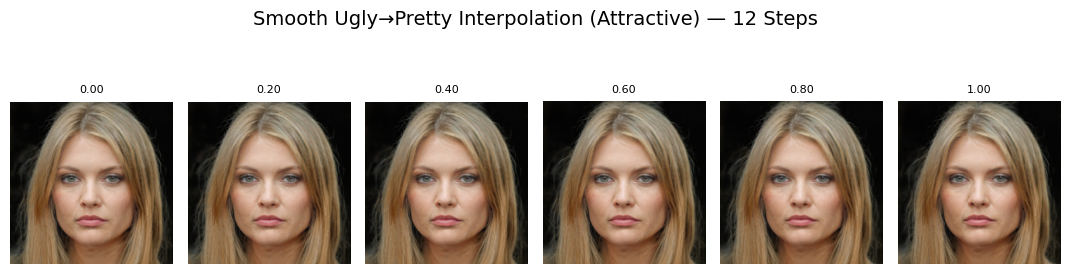

In [61]:
# %% code
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import get_concept_index

# 1) Settings
target_concept = 'Attractive'
n_steps        = 6
idx            = conc_clsf_classes.index(target_concept)
start, end     = get_concept_index(model, idx)

# 2) Sample one latent and get concept endpoints
z   = torch.randn((1, model.gen.z_dim), device=device)
w   = model.gen.mapping(z, None, truncation_psi=1.0)
c0  = model.cbae.enc(w)           # original (Not Attractive)
c1  = c0.clone()
c1[:, start:end] = 0
c1[:, start + 1] = 1.0            # set “Attractive” = on

# 3) Generate interpolated images
imgs = []
alphas = np.linspace(0, 1, n_steps)
for α in alphas:
    cα = c0 * (1 - α) + c1 * α
    wα = model.cbae.dec(cα)
    img = model.gen.synthesis(wα, noise_mode='const')
    img = img.clamp(-1,1).mul(0.5).add_(0.5)  # to [0,1]
    np_img = img[0].detach().cpu().permute(1,2,0).numpy()
    imgs.append(np_img)

# 4) Plot with larger figure size
fig, axes = plt.subplots(1, n_steps, figsize=(n_steps*1.8, 3))
for ax, im, α in zip(axes, imgs, alphas):
    ax.imshow(im)
    ax.set_title(f"{α:.2f}", fontsize=8)
    ax.axis('off')
plt.suptitle("Smooth Ugly→Pretty Interpolation (Attractive) — 12 Steps", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()